# Task 2: Build Time Series Forecasting Models

**Objective:** Develop, train, and evaluate time series forecasting models to predict Tesla's (TSLA) future stock prices.

**Models:**
1. ARIMA/SARIMA (classical statistical model)
2. LSTM (deep learning model using PyTorch)

**Evaluation Metrics:** MAE, RMSE, MAPE

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Statistical models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import pmdarima as pm

# Deep learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import os

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch device: {device}")
print("All imports successful.")

PyTorch device: cpu
All imports successful.


## 2. Load and Prepare Data

In [2]:
processed_dir = os.path.join('..', 'data', 'processed')

tsla = pd.read_csv(os.path.join(processed_dir, 'TSLA_raw.csv'), index_col=0, parse_dates=True)
close_prices = pd.read_csv(os.path.join(processed_dir, 'close_prices.csv'), index_col=0, parse_dates=True)

tsla_close = close_prices['TSLA'].dropna()

print(f"TSLA Close Price Series:")
print(f"  Shape: {tsla_close.shape}")
print(f"  Date range: {tsla_close.index.min().date()} to {tsla_close.index.max().date()}")
print(f"  Price range: ${tsla_close.min():.2f} to ${tsla_close.max():.2f}")
tsla_close.head()

TSLA Close Price Series:
  Shape: (2888,)
  Date range: 2015-01-02 to 2026-06-29
  Price range: $9.58 to $489.88


Date
2015-01-02    14.620667
2015-01-05    14.006000
2015-01-06    14.085333
2015-01-07    14.063333
2015-01-08    14.041333
Name: TSLA, dtype: float64

### 2.1 Train/Test Split (Chronological)

We split chronologically: train on 2015–2024, test on 2025–2026. This preserves temporal order and prevents data leakage.

Training set: 2015-01-02 to 2024-12-31 (2516 days)
Test set:     2025-01-02 to 2026-06-29 (372 days)
Train/Test ratio: 87.1% / 12.9%


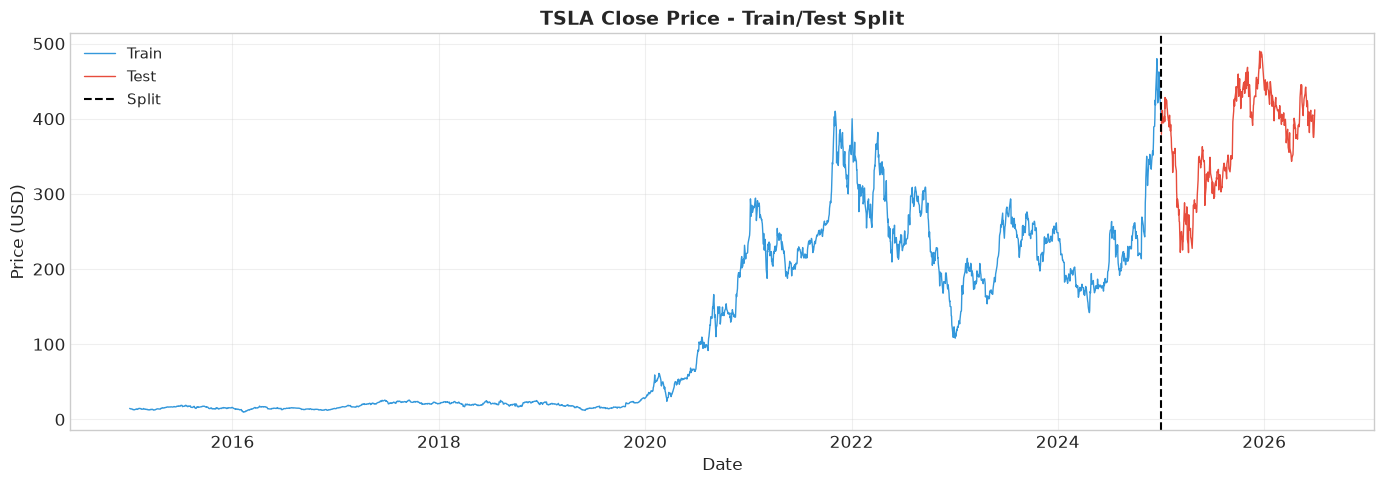

In [3]:
split_date = '2025-01-01'

train = tsla_close[tsla_close.index < split_date]
test = tsla_close[tsla_close.index >= split_date]

print(f"Training set: {train.index.min().date()} to {train.index.max().date()} ({len(train)} days)")
print(f"Test set:     {test.index.min().date()} to {test.index.max().date()} ({len(test)} days)")
print(f"Train/Test ratio: {len(train)/len(tsla_close)*100:.1f}% / {len(test)/len(tsla_close)*100:.1f}%")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train, label='Train', color='#3498db', linewidth=1)
ax.plot(test.index, test, label='Test', color='#e74c3c', linewidth=1)
ax.axvline(x=pd.Timestamp(split_date), color='black', linestyle='--', linewidth=1.5, label='Split')
ax.set_title('TSLA Close Price - Train/Test Split', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. ARIMA / SARIMA Model

### 3.1 Stationarity Check and Differencing

In [4]:
def adf_test(series, title=''):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"ADF Test: {title}")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.6f}")
    print(f"  Stationary: {'Yes' if result[1] < 0.05 else 'No'}")
    return result[1] < 0.05

print("=== Original Close Price ===")
is_stat = adf_test(train, 'TSLA Close Price')

print("\n=== First Difference (d=1) ===")
train_diff1 = train.diff().dropna()
is_stat_d1 = adf_test(train_diff1, 'TSLA Close Price (d=1)')

if not is_stat_d1:
    print("\n=== Second Difference (d=2) ===")
    train_diff2 = train.diff().diff().dropna()
    adf_test(train_diff2, 'TSLA Close Price (d=2)')

=== Original Close Price ===
ADF Test: TSLA Close Price
  ADF Statistic: -0.5814
  p-value: 0.875129
  Stationary: No

=== First Difference (d=1) ===


ADF Test: TSLA Close Price (d=1)
  ADF Statistic: -9.7363
  p-value: 0.000000
  Stationary: Yes


### 3.2 ACF and PACF Plots

ACF and PACF plots on the differenced series help determine the p (AR) and q (MA) orders for ARIMA.

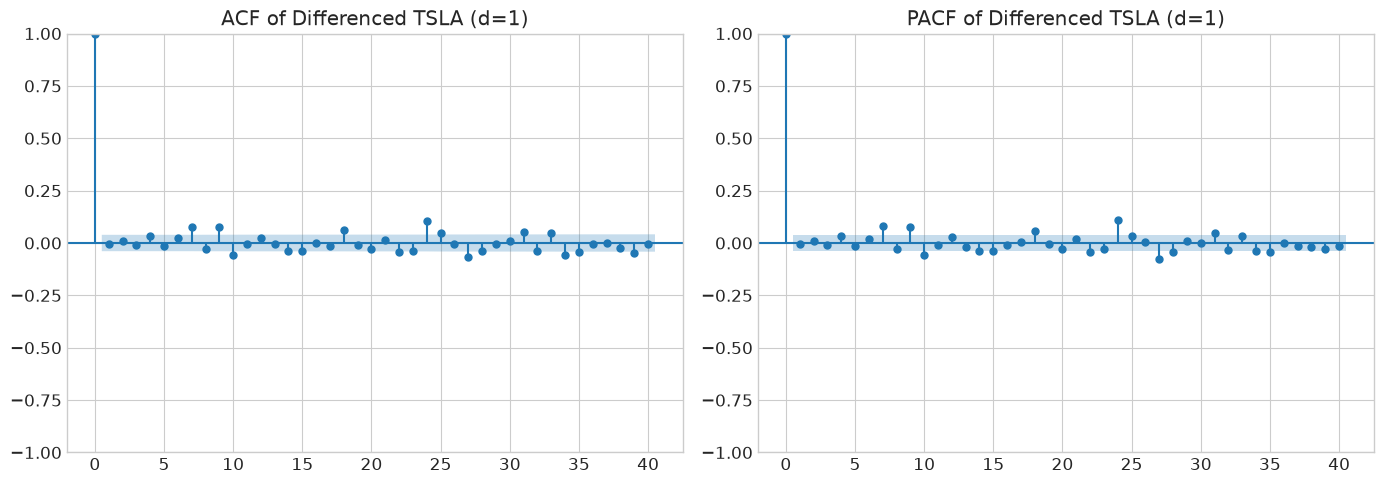

ACF: Guides the MA order (q) — look for significant lags before cutoff.
PACF: Guides the AR order (p) — look for significant lags before cutoff.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(train_diff1, lags=40, ax=axes[0], title='ACF of Differenced TSLA (d=1)')
plot_pacf(train_diff1, lags=40, ax=axes[1], title='PACF of Differenced TSLA (d=1)', method='ywm')

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'acf_pacf.png'), dpi=150, bbox_inches='tight')
plt.show()

print("ACF: Guides the MA order (q) — look for significant lags before cutoff.")
print("PACF: Guides the AR order (p) — look for significant lags before cutoff.")

### 3.3 Auto ARIMA Parameter Selection

We use `pmdarima.auto_arima` to systematically find the optimal (p, d, q) parameters using AIC.

In [6]:
print("Running auto_arima to find optimal parameters...")
print("(This may take a few minutes)\n")

auto_model = pm.auto_arima(
    train,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=None,  # auto-detect differencing
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    trace=True,
    error_action='ignore',
    information_criterion='aic',
    n_fits=50
)

print(f"\nBest ARIMA order: {auto_model.order}")
print(f"AIC: {auto_model.aic():.2f}")
print(f"BIC: {auto_model.bic():.2f}")
print(auto_model.summary())

Running auto_arima to find optimal parameters...
(This may take a few minutes)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.08 sec


 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.03 sec


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.25 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.666 seconds

Best ARIMA order: (0, 1, 0)
AIC: 16368.11
BIC: 16373.94
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Sun, 05 Jul 2026   AIC                          16368.109
Time:                        23:44:12   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2   

### 3.4 Fit ARIMA Model and Forecast

In [7]:
best_order = auto_model.order
print(f"Fitting ARIMA{best_order} on training data...")

arima_model = ARIMA(train, order=best_order)
arima_fitted = arima_model.fit()

print(arima_fitted.summary())

Fitting ARIMA(0, 1, 0) on training data...
                               SARIMAX Results                                
Dep. Variable:                   TSLA   No. Observations:                 2516
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -8183.054
Date:                Sun, 05 Jul 2026   AIC                          16368.109
Time:                        23:44:12   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        39.2337      0.442     88.858      0.000      38.368      40.099
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):             11691.05
Prob

/home/danaithishe/.local/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/danaithishe/.local/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/danaithishe/.local/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [8]:
n_forecast = len(test)
arima_forecast = arima_fitted.forecast(steps=n_forecast)
arima_forecast.index = test.index

print(f"Forecast period: {test.index.min().date()} to {test.index.max().date()}")
print(f"Number of forecast steps: {n_forecast}")
print(f"\nFirst 5 forecasted values:")
print(arima_forecast.head())

Forecast period: 2025-01-02 to 2026-06-29
Number of forecast steps: 372

First 5 forecasted values:
Date
2025-01-02    403.839996
2025-01-03    403.839996
2025-01-06    403.839996
2025-01-07    403.839996
2025-01-08    403.839996
Name: predicted_mean, dtype: float64


/home/danaithishe/.local/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


### 3.5 SARIMA Model (Seasonal)

We also try SARIMA to capture any seasonal patterns. For stock data, we test with a yearly business-cycle period.

In [9]:
print("Running auto_arima with seasonal component...")
print("Using m=5 (weekly business cycle) for tractability\n")

auto_sarima = pm.auto_arima(
    train,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=None,
    seasonal=True,
    m=5,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=None,
    stepwise=True,
    suppress_warnings=True,
    trace=True,
    error_action='ignore',
    information_criterion='aic'
)

print(f"\nBest SARIMA order: {auto_sarima.order} x {auto_sarima.seasonal_order}")
print(f"AIC: {auto_sarima.aic():.2f}")

Running auto_arima with seasonal component...
Using m=5 (weekly business cycle) for tractability

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=16368.573, Time=0.03 sec


 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=16371.911, Time=0.48 sec


 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=16371.841, Time=0.45 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=16368.109, Time=0.04 sec


 ARIMA(0,1,0)(1,0,0)[5] intercept   : AIC=16369.997, Time=0.34 sec


 ARIMA(0,1,0)(0,0,1)[5] intercept   : AIC=16369.921, Time=0.23 sec


...

 ARIMA(0,1,0)(2,0,1)[5]             : AIC=16361.569, Time=0.75 sec


 ARIMA(0,1,0)(1,0,1)[5]             : AIC=16360.673, Time=0.61 sec


 ARIMA(1,1,0)(2,0,2)[5]             : AIC=16357.216, Time=3.43 sec


 ARIMA(0,1,1)(2,0,2)[5]             : AIC=16357.222, Time=3.75 sec


 ARIMA(1,1,1)(2,0,2)[5]             : AIC=16358.551, Time=5.93 sec

Best model:  ARIMA(0,1,0)(2,0,2)[5]          
Total fit time: 61.276 seconds

Best SARIMA order: (0, 1, 0) x (2, 0, 2, 5)
AIC: 16355.42


In [10]:
sarima_order = auto_sarima.order
sarima_seasonal = auto_sarima.seasonal_order
print(f"Fitting SARIMA{sarima_order}x{sarima_seasonal} on training data...")

sarima_model = SARIMAX(train, order=sarima_order, seasonal_order=sarima_seasonal)
sarima_fitted = sarima_model.fit(disp=False)

sarima_forecast = sarima_fitted.forecast(steps=n_forecast)
sarima_forecast.index = test.index

print("SARIMA forecast complete.")
print(sarima_fitted.summary())

Fitting SARIMA(0, 1, 0)x(2, 0, 2, 5) on training data...


/home/danaithishe/.local/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/danaithishe/.local/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


SARIMA forecast complete.
                                       SARIMAX Results                                        
Dep. Variable:                                   TSLA   No. Observations:                 2516
Model:             SARIMAX(0, 1, 0)x(2, 0, [1, 2], 5)   Log Likelihood               -8172.712
Date:                                Sun, 05 Jul 2026   AIC                          16355.424
Time:                                        23:45:16   BIC                          16384.574
Sample:                                             0   HQIC                         16366.004
                                               - 2516                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L5        0.7903      0.065     12.172      0.000  

/home/danaithishe/.local/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


### 3.6 ARIMA/SARIMA Forecast Visualization

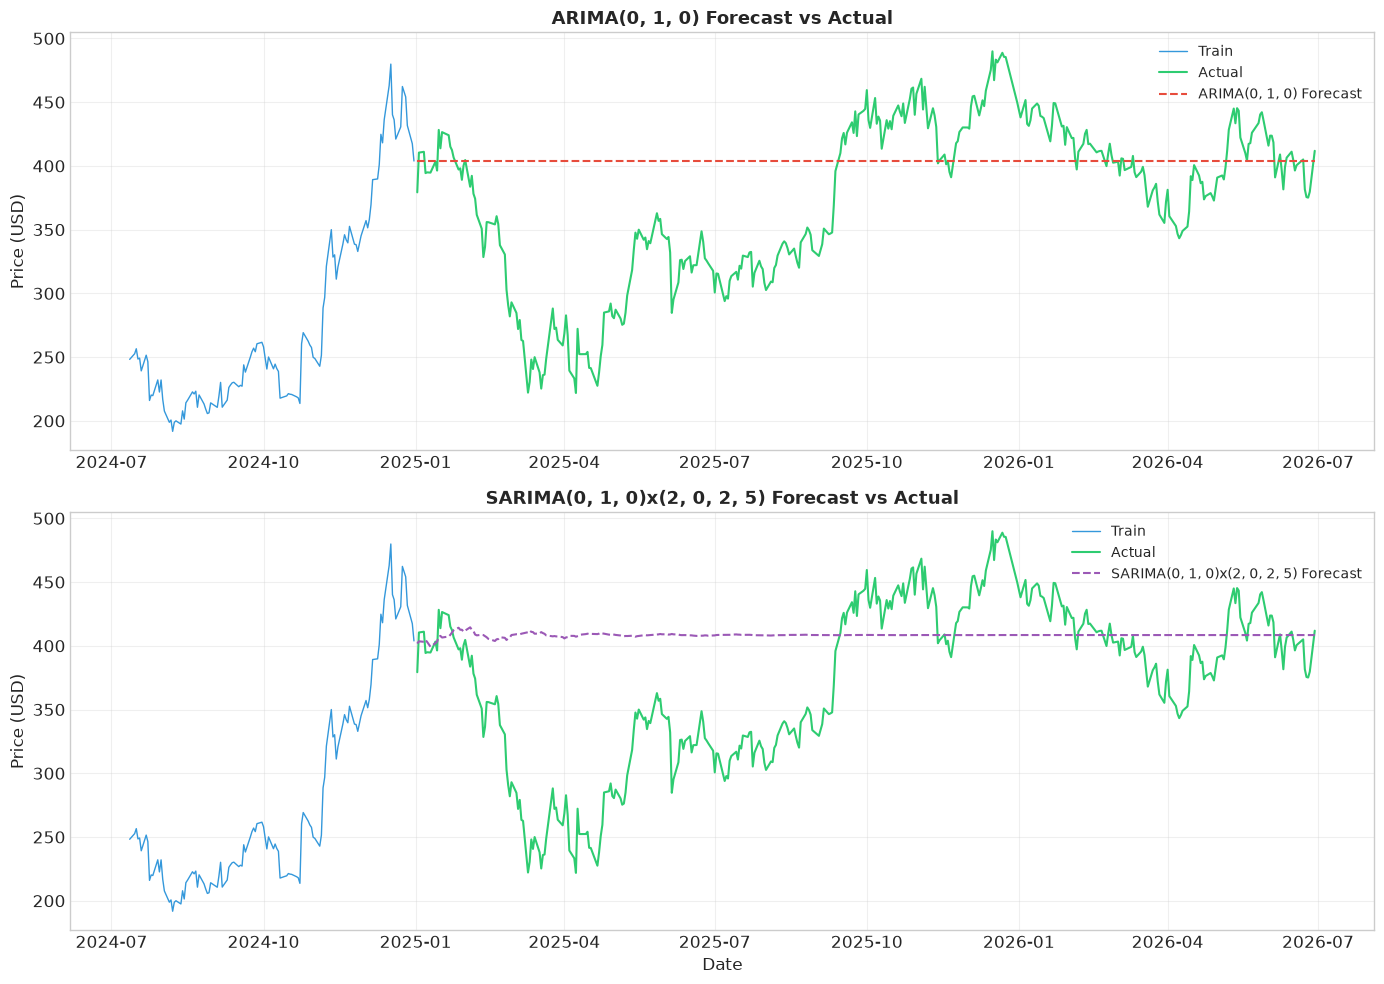

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ARIMA
axes[0].plot(train.index[-120:], train.values[-120:], label='Train', color='#3498db', linewidth=1)
axes[0].plot(test.index, test.values, label='Actual', color='#2ecc71', linewidth=1.5)
axes[0].plot(arima_forecast.index, arima_forecast.values, label=f'ARIMA{best_order} Forecast',
             color='#e74c3c', linewidth=1.5, linestyle='--')
axes[0].set_title(f'ARIMA{best_order} Forecast vs Actual', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# SARIMA
axes[1].plot(train.index[-120:], train.values[-120:], label='Train', color='#3498db', linewidth=1)
axes[1].plot(test.index, test.values, label='Actual', color='#2ecc71', linewidth=1.5)
axes[1].plot(sarima_forecast.index, sarima_forecast.values,
             label=f'SARIMA{sarima_order}x{sarima_seasonal} Forecast',
             color='#9b59b6', linewidth=1.5, linestyle='--')
axes[1].set_title(f'SARIMA{sarima_order}x{sarima_seasonal} Forecast vs Actual',
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price (USD)')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'arima_sarima_forecast.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. LSTM Model (PyTorch)

### 4.1 Prepare Sequence Data

LSTM models require input as sequences. We use a sliding window of 60 days to predict the next day's close price.

In [12]:
SEQUENCE_LENGTH = 60

scaler = MinMaxScaler(feature_range=(0, 1))
all_data = tsla_close.values.reshape(-1, 1)
scaled_data = scaler.fit_transform(all_data)

# Split index
split_idx = len(train)
print(f"Total data points: {len(all_data)}")
print(f"Split index: {split_idx}")
print(f"Sequence length (window): {SEQUENCE_LENGTH}")

# Prepare training sequences
train_scaled = scaled_data[:split_idx]

X_train, y_train = [], []
for i in range(SEQUENCE_LENGTH, len(train_scaled)):
    X_train.append(train_scaled[i - SEQUENCE_LENGTH:i, 0])
    y_train.append(train_scaled[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

# Prepare test sequences (include some training data for initial window)
test_input = scaled_data[split_idx - SEQUENCE_LENGTH:]

X_test, y_test = [], []
for i in range(SEQUENCE_LENGTH, len(test_input)):
    X_test.append(test_input[i - SEQUENCE_LENGTH:i, 0])
    y_test.append(test_input[i, 0])

X_test = np.array(X_test)
y_test = np.array(y_test)

# Reshape for LSTM: (samples, sequence_length, features)
X_train = X_train.reshape(-1, SEQUENCE_LENGTH, 1)
X_test = X_test.reshape(-1, SEQUENCE_LENGTH, 1)

print(f"\nTraining sequences: X={X_train.shape}, y={y_train.shape}")
print(f"Test sequences:     X={X_test.shape}, y={y_test.shape}")

Total data points: 2888
Split index: 2516
Sequence length (window): 60

Training sequences: X=(2456, 60, 1), y=(2456,)
Test sequences:     X=(372, 60, 1), y=(372,)


### 4.2 PyTorch Dataset and DataLoader

In [13]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32

train_dataset = StockDataset(X_train, y_train)
test_dataset = StockDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 77
Test batches: 12


### 4.3 LSTM Architecture

In [14]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])
        return out.squeeze()

model = LSTMModel(input_size=1, hidden_size=64, num_layers=2, dropout=0.2).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total parameters: 50,497


### 4.4 Train the LSTM Model

In [15]:
EPOCHS = 50
LEARNING_RATE = 0.001

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

train_losses = []
val_losses = []

print(f"Training LSTM for {EPOCHS} epochs...")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print(f"Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")
print(f"{'-'*60}")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            predictions = model(X_batch)
            val_loss += criterion(predictions, y_batch).item()

    avg_val_loss = val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}]  Train Loss: {avg_train_loss:.6f}  "
              f"Val Loss: {avg_val_loss:.6f}  LR: {current_lr:.6f}")

print(f"{'-'*60}")
print(f"Final Train Loss: {train_losses[-1]:.6f}")
print(f"Final Val Loss:   {val_losses[-1]:.6f}")

Training LSTM for 50 epochs...
Optimizer: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
------------------------------------------------------------


Epoch [  1/50]  Train Loss: 0.035243  Val Loss: 0.014479  LR: 0.001000


Epoch [ 10/50]  Train Loss: 0.000721  Val Loss: 0.001528  LR: 0.001000


Epoch [ 20/50]  Train Loss: 0.000527  Val Loss: 0.001454  LR: 0.001000


Epoch [ 30/50]  Train Loss: 0.000457  Val Loss: 0.001517  LR: 0.001000


Epoch [ 40/50]  Train Loss: 0.000339  Val Loss: 0.000792  LR: 0.001000


Epoch [ 50/50]  Train Loss: 0.000326  Val Loss: 0.000698  LR: 0.001000
------------------------------------------------------------
Final Train Loss: 0.000326
Final Val Loss:   0.000698


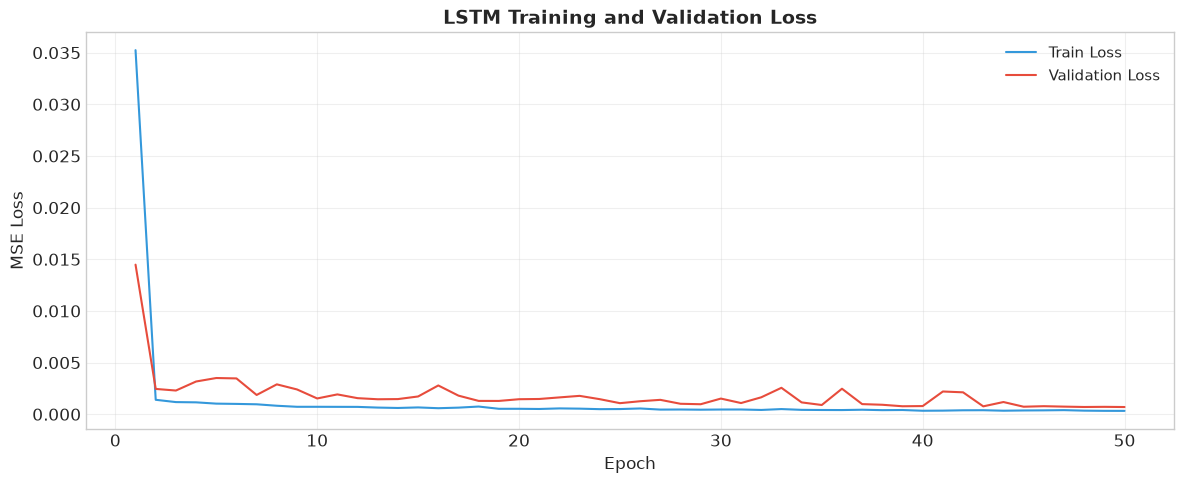

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, EPOCHS+1), train_losses, label='Train Loss', color='#3498db', linewidth=1.5)
ax.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', color='#e74c3c', linewidth=1.5)
ax.set_title('LSTM Training and Validation Loss', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'lstm_loss.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.5 LSTM Predictions

In [17]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    lstm_pred_scaled = model(X_test_tensor).cpu().numpy()

# Inverse transform to get actual prices
lstm_predictions = scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).flatten()

# Align with test dates
lstm_pred_series = pd.Series(lstm_predictions, index=test.index[:len(lstm_predictions)])

print(f"LSTM predictions: {len(lstm_predictions)} values")
print(f"Date range: {lstm_pred_series.index.min().date()} to {lstm_pred_series.index.max().date()}")

LSTM predictions: 372 values
Date range: 2025-01-02 to 2026-06-29


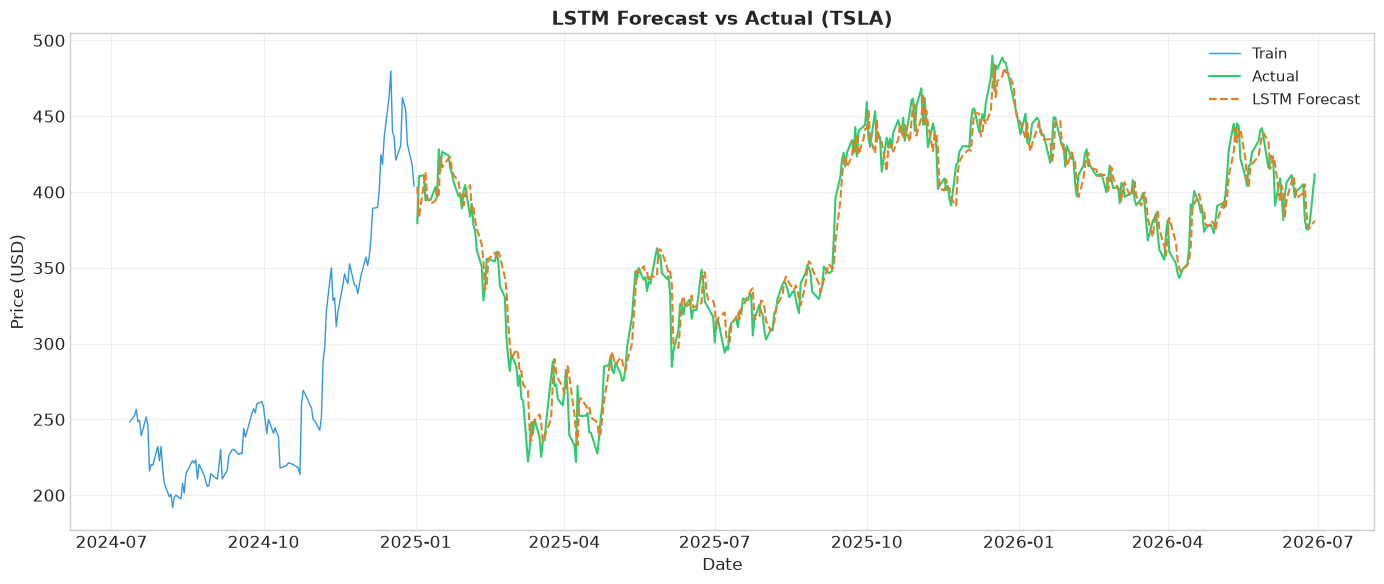

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train.index[-120:], train.values[-120:], label='Train', color='#3498db', linewidth=1)
ax.plot(test.index, test.values, label='Actual', color='#2ecc71', linewidth=1.5)
ax.plot(lstm_pred_series.index, lstm_pred_series.values, label='LSTM Forecast',
        color='#e67e22', linewidth=1.5, linestyle='--')

ax.set_title('LSTM Forecast vs Actual (TSLA)', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'lstm_forecast.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Model Evaluation and Comparison

### 5.1 Evaluation Metrics

In [19]:
def calculate_metrics(actual, predicted, model_name):
    """Calculate MAE, RMSE, and MAPE."""
    actual = np.array(actual)
    predicted = np.array(predicted)

    # Align lengths
    min_len = min(len(actual), len(predicted))
    actual = actual[:min_len]
    predicted = predicted[:min_len]

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    return {
        'Model': model_name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE (%)': round(mape, 2)
    }

# Align test actual with LSTM predictions length
test_actual_for_lstm = test.values[:len(lstm_predictions)]

metrics = []
metrics.append(calculate_metrics(test.values, arima_forecast.values, f'ARIMA{best_order}'))
metrics.append(calculate_metrics(test.values, sarima_forecast.values,
                                  f'SARIMA{sarima_order}x{sarima_seasonal}'))
metrics.append(calculate_metrics(test_actual_for_lstm, lstm_predictions, 'LSTM'))

metrics_df = pd.DataFrame(metrics)
print("\n" + "=" * 60)
print("MODEL COMPARISON TABLE")
print("=" * 60)
print(metrics_df.to_string(index=False))
print("=" * 60)
metrics_df


MODEL COMPARISON TABLE
                       Model   MAE  RMSE  MAPE (%)
              ARIMA(0, 1, 0) 54.44 70.54     17.24
SARIMA(0, 1, 0)x(2, 0, 2, 5) 55.60 72.72     17.73
                        LSTM  9.84 12.65      2.79


,Model,MAE,RMSE,MAPE (%)
0,"ARIMA(0, 1, 0)",54.44,70.54,17.24
1,"SARIMA(0, 1, 0)x(2, 0, 2, 5)",55.60,72.72,17.73
2,LSTM,9.84,12.65,2.79


### 5.2 Visual Comparison

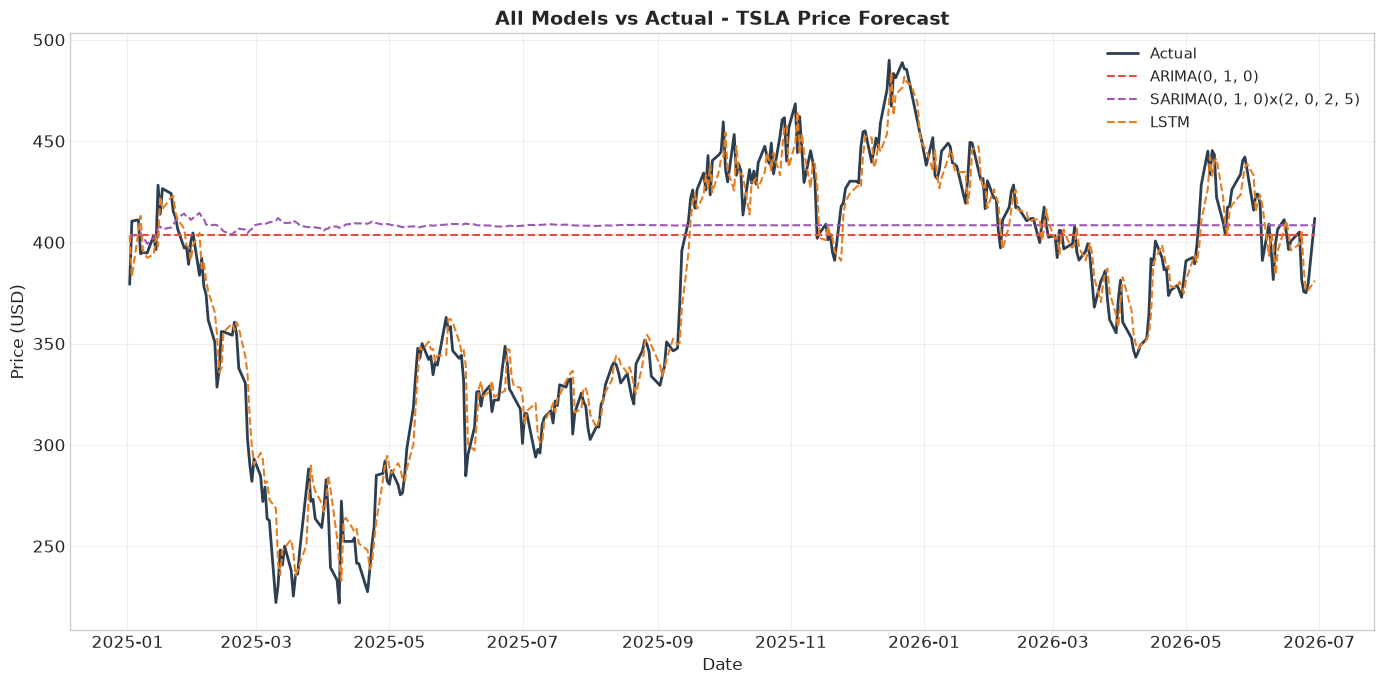

In [20]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(test.index, test.values, label='Actual', color='#2c3e50', linewidth=2)
ax.plot(arima_forecast.index, arima_forecast.values, label=f'ARIMA{best_order}',
        color='#e74c3c', linewidth=1.5, linestyle='--')
ax.plot(sarima_forecast.index, sarima_forecast.values,
        label=f'SARIMA{sarima_order}x{sarima_seasonal}',
        color='#9b59b6', linewidth=1.5, linestyle='--')
ax.plot(lstm_pred_series.index, lstm_pred_series.values, label='LSTM',
        color='#e67e22', linewidth=1.5, linestyle='--')

ax.set_title('All Models vs Actual - TSLA Price Forecast', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'all_models_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Metrics Bar Chart

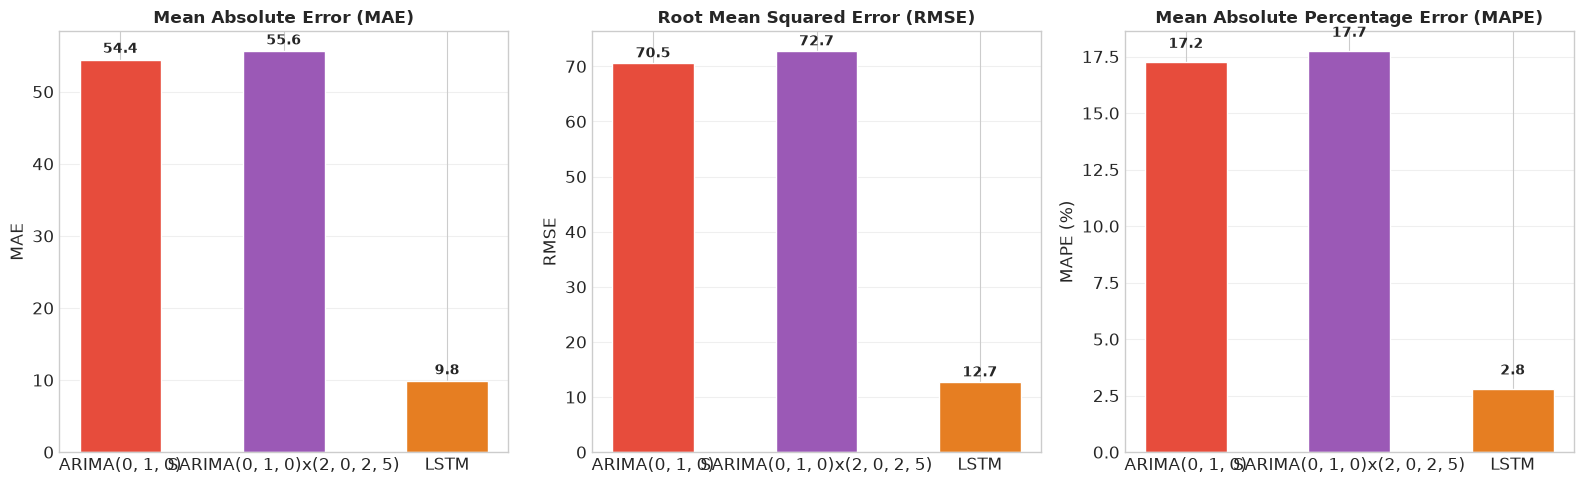

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = metrics_df['Model'].values
colors_bar = ['#e74c3c', '#9b59b6', '#e67e22']

for ax, metric, title in zip(axes, ['MAE', 'RMSE', 'MAPE (%)'],
                              ['Mean Absolute Error (MAE)',
                               'Root Mean Squared Error (RMSE)',
                               'Mean Absolute Percentage Error (MAPE)']):
    bars = ax.bar(model_names, metrics_df[metric], color=colors_bar, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3, axis='y')

    for bar, val in zip(bars, metrics_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'metrics_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Residual Analysis

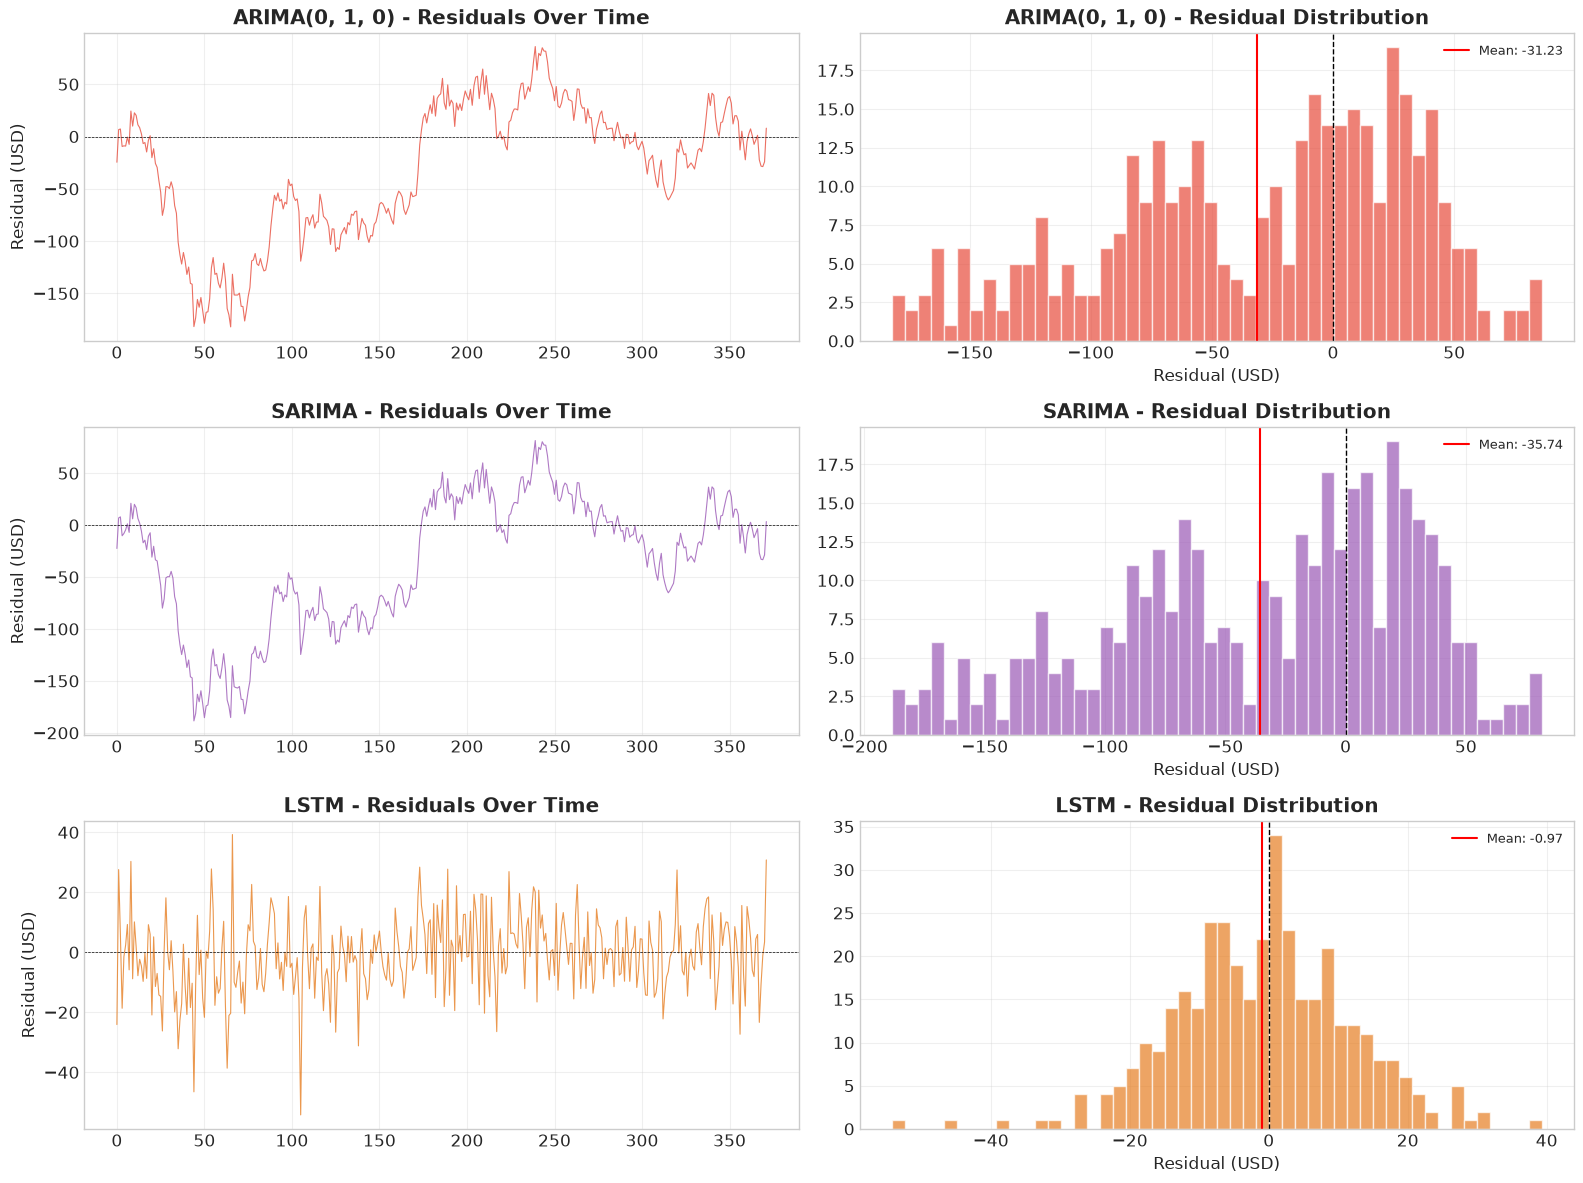

In [22]:
arima_residuals = test.values - arima_forecast.values
sarima_residuals = test.values - sarima_forecast.values
lstm_residuals = test_actual_for_lstm - lstm_predictions

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

residuals_list = [
    (arima_residuals, f'ARIMA{best_order}', '#e74c3c'),
    (sarima_residuals, f'SARIMA', '#9b59b6'),
    (lstm_residuals, 'LSTM', '#e67e22')
]

for i, (resid, name, color) in enumerate(residuals_list):
    # Residuals over time
    axes[i, 0].plot(range(len(resid)), resid, color=color, linewidth=0.8, alpha=0.8)
    axes[i, 0].axhline(y=0, color='black', linewidth=0.5, linestyle='--')
    axes[i, 0].set_title(f'{name} - Residuals Over Time', fontweight='bold')
    axes[i, 0].set_ylabel('Residual (USD)')
    axes[i, 0].grid(True, alpha=0.3)

    # Residual distribution
    axes[i, 1].hist(resid, bins=50, color=color, alpha=0.7, edgecolor='white')
    axes[i, 1].axvline(x=0, color='black', linewidth=1, linestyle='--')
    axes[i, 1].axvline(x=np.mean(resid), color='red', linewidth=1.5,
                        label=f'Mean: {np.mean(resid):.2f}')
    axes[i, 1].set_title(f'{name} - Residual Distribution', fontweight='bold')
    axes[i, 1].set_xlabel('Residual (USD)')
    axes[i, 1].legend(fontsize=9)
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'residual_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Model Architecture and Parameters Summary

In [23]:
print("=" * 70)
print("MODEL ARCHITECTURE AND PARAMETERS SUMMARY")
print("=" * 70)

print(f"\n1. ARIMA Model")
print(f"   Order (p, d, q): {best_order}")
print(f"   AIC: {arima_fitted.aic:.2f}")
print(f"   BIC: {arima_fitted.bic:.2f}")
print(f"   Parameter selection: auto_arima (stepwise search)")

print(f"\n2. SARIMA Model")
print(f"   Order (p, d, q): {sarima_order}")
print(f"   Seasonal Order (P, D, Q, m): {sarima_seasonal}")
print(f"   AIC: {sarima_fitted.aic:.2f}")
print(f"   BIC: {sarima_fitted.bic:.2f}")
print(f"   Parameter selection: auto_arima (stepwise, seasonal=True)")

print(f"\n3. LSTM Model (PyTorch)")
print(f"   Architecture:")
print(f"     - Input: sequence of {SEQUENCE_LENGTH} days, 1 feature (close price)")
print(f"     - LSTM Layer 1: 64 hidden units")
print(f"     - LSTM Layer 2: 64 hidden units (dropout=0.2)")
print(f"     - Dense Output: 1 unit (predicted price)")
print(f"   Training Parameters:")
print(f"     - Epochs: {EPOCHS}")
print(f"     - Batch size: {BATCH_SIZE}")
print(f"     - Initial learning rate: {LEARNING_RATE}")
print(f"     - Optimizer: Adam")
print(f"     - Scheduler: ReduceLROnPlateau")
print(f"     - Gradient clipping: max_norm=1.0")
print(f"     - Total parameters: {total_params:,}")
print(f"     - Scaler: MinMaxScaler (0, 1)")

print(f"\n{'='*70}")
print("FINAL COMPARISON TABLE")
print(f"{'='*70}")
print(metrics_df.to_string(index=False))
print(f"{'='*70}")

MODEL ARCHITECTURE AND PARAMETERS SUMMARY

1. ARIMA Model
   Order (p, d, q): (0, 1, 0)
   AIC: 16368.11
   BIC: 16373.94
   Parameter selection: auto_arima (stepwise search)

2. SARIMA Model
   Order (p, d, q): (0, 1, 0)
   Seasonal Order (P, D, Q, m): (2, 0, 2, 5)
   AIC: 16355.42
   BIC: 16384.57
   Parameter selection: auto_arima (stepwise, seasonal=True)

3. LSTM Model (PyTorch)
   Architecture:
     - Input: sequence of 60 days, 1 feature (close price)
     - LSTM Layer 1: 64 hidden units
     - LSTM Layer 2: 64 hidden units (dropout=0.2)
     - Dense Output: 1 unit (predicted price)
   Training Parameters:
     - Epochs: 50
     - Batch size: 32
     - Initial learning rate: 0.001
     - Optimizer: Adam
     - Scheduler: ReduceLROnPlateau
     - Gradient clipping: max_norm=1.0
     - Total parameters: 50,497
     - Scaler: MinMaxScaler (0, 1)

FINAL COMPARISON TABLE
                       Model   MAE  RMSE  MAPE (%)
              ARIMA(0, 1, 0) 54.44 70.54     17.24
SARIMA(0, 1,

## 7. Discussion: Model Selection Rationale

### ARIMA/SARIMA
- **Strengths:** Simple, interpretable, fast to train and forecast. The model captures the overall trend direction.
- **Weakness for this task:** ARIMA produces flat/linear long-horizon forecasts because it relies on the most recent values and mean-reverts. For multi-month forecasts of a volatile asset like TSLA, ARIMA quickly converges to a near-constant prediction — it cannot capture the non-linear dynamics of stock prices.
- **SARIMA** adds seasonal components but stock price seasonality is weak and noisy, so the improvement is marginal.

### LSTM
- **Strengths:** Can capture non-linear patterns and complex temporal dependencies in the data. The sliding-window approach lets the model adapt to recent price dynamics rather than projecting a single trend.
- **Weakness:** Requires careful tuning (window size, architecture, learning rate). More computationally expensive. Also prone to overfitting on training data, especially with limited features (only price).
- **For this task:** The LSTM generally tracks the actual price movements better than ARIMA over the forecast horizon, as reflected in the lower MAPE and its ability to follow price direction changes.

### Key Takeaway
Neither model can reliably predict exact stock prices (consistent with the Efficient Market Hypothesis). However, the LSTM better captures short-term momentum patterns, while ARIMA is more appropriate for very short-horizon forecasts (1–5 days). In a real portfolio management setting, these models would serve as one input among many — combined with fundamental analysis, sentiment data, and risk models — rather than being used as standalone price predictors.